In [2]:
from evo.tools import file_interface
from evo.core import sync
from evo.core import metrics
from evo.core.geometry import GeometryException
import matplotlib.pyplot as plt
from evo.core.units import Unit
from rosbags.rosbag1 import Reader
from numpy import mean
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pprint, os, math

In [21]:
def single_traj(traj):
    xy = traj.positions_xyz
    x = xy[:,0]
    y = xy[:,1]
    z = xy[:,2]
    qo = traj.orientations_quat_wxyz
    all = {
        'timestamp':traj.timestamps,
        'x':x,
        'y':y,
        'z':z,
        'q_x': qo[:,0],
        'q_y': qo[:,1],
        'q_z': qo[:,2],
        'q_w': qo[:,3],
    }
    return pd.DataFrame(data=all)

def write_tum(df:pd.DataFrame, name:str):
    with open(name, 'w') as file:
        for row in df.iloc:
            file.write(' '.join([str(row[key]) for key in df.keys()])+'\n')

def clean_traj(traj_df:pd.DataFrame):
    mask = ~((traj_df['x'] == traj_df['x'].shift()) & (traj_df['y'] == traj_df['y'].shift()))
    return traj_df[mask]

def traj_to_tum(gt_traj, odom_traj, gt_name, odom_name, clean_trajectory=False):
    gt = single_traj(gt_traj)
    odom = single_traj(odom_traj)
    if clean_trajectory:
        gt = clean_traj(gt)
        idxs = gt.index
        odom = odom.iloc[idxs]
    write_tum(gt, gt_name)
    write_tum(odom, odom_name)

def get_speedup(maps_nr:int, bag:str) -> int:
    wall_duration = maps_nr*30
    with Reader(bag) as reader:
        ros_duration = reader.duration
    return round(ros_duration/10**9/wall_duration)

def get_map_nr(path:str):
    # path: main path of the bag
    return len([file for file in os.listdir(f'{path}{'/' if path else ''}Maps') if file.endswith('Map.png') and file!='Map.png'])

def make_APE_log(path:str, APE:dict):
    '''
    path: main path of the bag
     APE: {'ATE':[x1,...,xn],'ARE':[y1,...,yn]} (n=maps_number)
    ''' 
    n = len(APE['ATE'])
    for i in range(n):
        with open(f'{path}{'/' if path else ''}Maps/{i}APE.yaml','w') as file:
            file.write(f'ate: {APE['ATE'][i]}\nare: {APE['ARE'][i]}\nape: {APE['APE'][i]}')

In [23]:
map_freq = 30
path = 'ros-exploration-config/output'
names = os.listdir(path)
c = 0
check = []
for name in names:
    main_path = f'{path}/{name}/run1'
    bag = f'{main_path}/{name}.bag'
    if any((file.endswith('APE.yaml') for file in os.listdir(f'{main_path}/Maps'))):
        continue
    with Reader(bag) as reader:
        traj_est = file_interface.read_bag_trajectory(reader,'/odom')
        traj_ref = file_interface.read_bag_trajectory(reader,'/base_pose_ground_truth')
    try:
        traj_est.align(traj_ref,correct_scale=True)                             # do it before the tum conversion and cleaning!
    except GeometryException:
        print(f'RUN ROTTA: {bag}')
        continue
    real_ts = traj_est.timestamps                                  
    step = math.floor(len(real_ts)/(get_map_nr(main_path)-1))
    real_ts_stepped = real_ts[::step]

    traj_to_tum(traj_ref, traj_est, f'{main_path}/gt.tum', f'{main_path}/odom.tum', clean_trajectory=True)
    traj_est = file_interface.read_tum_trajectory_file(f'{main_path}/odom.tum')
    traj_ref = file_interface.read_tum_trajectory_file(f'{main_path}/gt.tum')
    if len(traj_ref.timestamps)!=len(traj_est.timestamps):
        print(f'RUN ROTTA! {bag}')
        check += [bag]
    ate_metric = metrics.APE(metrics.PoseRelation.translation_part)
    ate_metric.process_data((traj_ref, traj_est))
    are_metric = metrics.APE(metrics.PoseRelation.rotation_part)
    are_metric.process_data((traj_ref, traj_est))
    ape_metric = metrics.APE(metrics.PoseRelation.full_transformation)
    ape_metric.process_data((traj_ref, traj_est))

    ts = traj_est.timestamps                                                    # filtered timestamps
    useless_maps_ts = [x for x in real_ts_stepped if x>ts[-1]]                  # timestamp of the maps that was taken after the robot final stop
    useless_maps_n = len(useless_maps_ts)       
    if useless_maps_n>1:                      
        useful_maps_ts = real_ts_stepped[:-(useless_maps_n-1)]                  # all the useful maps + the last useless one
    else:
        useful_maps_ts = real_ts_stepped
    useful_maps_idxs = [int(np.searchsorted(ts,v)) for v in useful_maps_ts]     # time indexes related to png maps
    useful_maps_idxs[-1] = useful_maps_idxs[-1]-1

    stats = {
        'ATE': ate_metric.error[useful_maps_idxs],
        'ARE': are_metric.error[useful_maps_idxs],
        'APE': ape_metric.error[useful_maps_idxs],
    }
    make_APE_log(main_path, stats)
    c+=1
    print(c)

RUN ROTTA: ros-exploration-config/output/0510030968_A-40/run1/0510030968_A-40.bag
RUN ROTTA: ros-exploration-config/output/0510032192_A_40_1_103/run1/0510032192_A_40_1_103.bag
RUN ROTTA: ros-exploration-config/output/0510032194_A_40_1_102/run1/0510032194_A_40_1_102.bag
RUN ROTTA: ros-exploration-config/output/0510032194_A_40_1_202/run1/0510032194_A_40_1_202.bag
RUN ROTTA: ros-exploration-config/output/0510032258_A_40_1_105/run1/0510032258_A_40_1_105.bag
RUN ROTTA: ros-exploration-config/output/0510032268_A_40_1_102/run1/0510032268_A_40_1_102.bag
RUN ROTTA: ros-exploration-config/output/0510032271_A_40_1_105/run1/0510032271_A_40_1_105.bag
RUN ROTTA: ros-exploration-config/output/0510034691_Layout1/run1/0510034691_Layout1.bag
RUN ROTTA: ros-exploration-config/output/0510034692_Layout1/run1/0510034692_Layout1.bag
RUN ROTTA: ros-exploration-config/output/0510034693_Layout1/run1/0510034693_Layout1.bag
RUN ROTTA: ros-exploration-config/output/0510034839_A-40.1-101/run1/0510034839_A-40.1-101.

In [12]:
with Reader(bag) as reader:
    traj_est = file_interface.read_bag_trajectory(reader,'/odom')
    traj_ref = file_interface.read_bag_trajectory(reader,'/base_pose_ground_truth')

In [18]:
clean_traj(single_traj(traj_ref)).index

Index([    0,   256,   257,   258,   259,   263,   264,   265,   266,   267,
       ...
       86074, 86075, 86076, 86077, 86078, 86079, 86080, 86081, 86082, 86125],
      dtype='int64', length=39279)

In [20]:
single_traj(traj_est).iloc[clean_traj(single_traj(traj_ref)).index]

,timestamp,x,y,z,q_x,q_y,q_z,q_w
0,0.9,0.000000,0.000000,0.0,1.000000,0.0,0.0,0.000000
256,26.5,0.151616,-0.094289,0.0,0.936572,0.0,0.0,-0.350474
257,26.6,0.172874,-0.114743,0.0,0.927519,0.0,0.0,-0.373776
258,26.7,0.175956,-0.118021,0.0,0.917886,0.0,0.0,-0.396845
259,26.8,0.178876,-0.121445,0.0,0.907998,0.0,0.0,-0.418974
...,...,...,...,...,...,...,...,...
86079,8608.8,12.816085,-38.676579,0.0,0.764442,0.0,0.0,-0.644693
86080,8608.9,12.816754,-38.681048,0.0,0.757584,0.0,0.0,-0.652738
86081,8609.0,12.817341,-38.685528,0.0,0.751638,0.0,0.0,-0.659575
86082,8609.1,12.817867,-38.690016,0.0,0.747170,0.0,0.0,-0.664633


In [5]:
check

['ros-exploration-config/output/0510034868_A-40/run1/0510034868_A-40.bag',
 'ros-exploration-config/output/E53-4/run1/E53-4.bag',
 'ros-exploration-config/output/N57-1/run1/N57-1.bag',
 'ros-exploration-config/output/W1-0/run1/W1-0.bag']

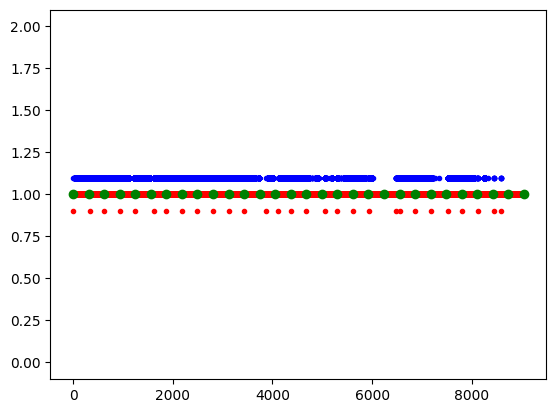

In [6]:
TS = traj_est.timestamps
useless_maps_ts = [x for x in real_ts_stepped if x>TS[-1]]                       # timestamp of the maps that was taken after the robot final stop
useless_maps_n = len(useless_maps_ts)                   
if useless_maps_n>1:                                           # i take only the first one
    last_maps_ts = useless_maps_ts[0]
    useful_maps_ts = real_ts_stepped[:-(useless_maps_n-1)]                      # all the useful maps + the last useless one
else:
    useful_maps_ts = real_ts_stepped
useful_maps_idxs = [int(np.searchsorted(TS,v)) for v in useful_maps_ts]     # time indexes related to maps
useful_maps_idxs[-1] = useful_maps_idxs[-1]-1
plt.plot(real_ts,[1]*len(real_ts),'r.')
plt.plot(TS,[1.1]*len(TS),'b.')
plt.plot(real_ts_stepped,[1]*len(real_ts_stepped),'go')
plt.plot(0,2)
plt.plot(0,0)
plt.plot(TS[useful_maps_idxs],[0.9]*len(useful_maps_idxs),'r.')

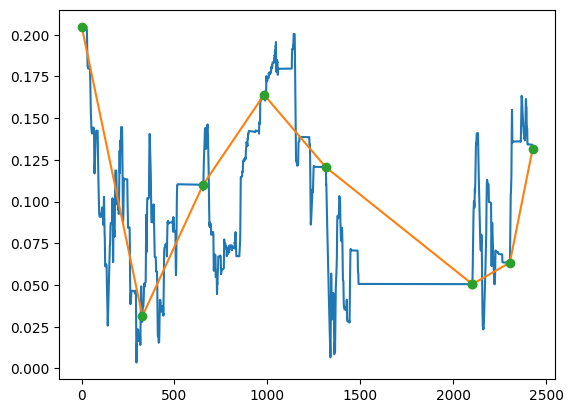

In [ ]:
plt.plot(traj_est.timestamps,ape_metric.error)
plt.plot(TS[useful_maps_idxs],ape_metric.error[useful_maps_idxs])
plt.plot(TS[useful_maps_idxs],ape_metric.error[useful_maps_idxs],'o')